Loading dataset
Cleaning data
Training models
Evaluating (F1-score)
Saving the model

In [17]:
import pandas as pd
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder


In [18]:
df = pd.read_csv("../data/raw/ar_reviews_100k.tsv", sep="\t")

print(df.head())


      label                                               text
0  Positive  ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1  Positive  أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2  Positive  هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3  Positive  خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4  Positive  ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


In [19]:
print(df.columns)
print(df.shape)

Index(['label', 'text'], dtype='object')
(99999, 2)


In [20]:
print(df['label'].value_counts())

label
Positive    33333
Mixed       33333
Negative    33333
Name: count, dtype: int64


In [21]:
def clean_text(text):
    text = str(text)

    # Remove links
    text = re.sub(r"http\S+", "", text)
    
    # Remove mentions (@user)
    text = re.sub(r"@\w+", "", text)
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove punctuation (keep Arabic letters only)
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)
    
    # Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

df['text'] = df['text'].apply(clean_text)

In [22]:
df.isnull().sum()

# remove empty and null text entries
df = df[df['text'].notnull()]
df = df[df['text'] != ""]

In [23]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),   # words + word pairs
    min_df=2,
    max_df=0.9
)

X = vectorizer.fit_transform(df['text'])
y = df['label']

print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3715560 stored elements and shape (99998, 10000)>
  Coords	Values
  (0, 8259)	0.3181430800453854
  (0, 8775)	0.40406738579220575
  (0, 7655)	0.2064017444088505
  (0, 2746)	0.3250757520676367
  (0, 9093)	0.49762159689572716
  (0, 2547)	0.4076983626883543
  (0, 8776)	0.41640532542837855
  (1, 140)	0.11642229535354577
  (1, 318)	0.16645933196724064
  (1, 8643)	0.1873604260977405
  (1, 893)	0.3453637490926265
  (1, 2949)	0.06020128068341829
  (1, 7012)	0.14614843920099568
  (1, 5403)	0.13029352629471763
  (1, 6346)	0.045929909382955984
  (1, 8832)	0.0890878354344177
  (1, 1428)	0.16031595028281445
  (1, 8662)	0.14081177460343147
  (1, 8660)	0.19436957275521635
  (1, 8289)	0.045066869475534434
  (1, 6273)	0.1692627138086039
  (1, 8693)	0.19342254286783683
  (1, 951)	0.12194424745078129
  (1, 7125)	0.06104152313336992
  (1, 9859)	0.20009528824104084
  :	:
  (99996, 3358)	0.25133195357257937
  (99996, 9104)	0.23401570965030127
  (9

In [24]:
# Encoder manually
# df['label'] = df['label'].map({
#     'negative': 0,
#     'mixed': 1,
#     'positive': 2
# })

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [25]:
print(df['label'].unique())
print(df['label'].value_counts())
print(le.classes_)


[2 0 1]
label
2    33333
1    33333
0    33332
Name: count, dtype: int64
['Mixed' 'Negative' 'Positive']


In [26]:
print(df['label'].value_counts())
print(df['label'][5900])

label
2    33333
1    33333
0    33332
Name: count, dtype: int64
2


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [29]:
lr = LogisticRegression(max_iter=2000, C=1.5)
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [30]:
svm = LinearSVC(C=1.5)
svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.5
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [32]:
from sklearn.metrics import f1_score

models = {
    "Naive Bayes": nb,
    "Logistic Regression": lr,
    "SVM": svm
}

f1_scores = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    f1_scores[name] = f1
    
    print(name, "F1-score:", f1)

Naive Bayes F1-score: 0.6588860928820622
Logistic Regression F1-score: 0.6753450790692603
SVM F1-score: 0.6614770478900954


In [33]:
best_model = svm  # replace with best result

In [34]:
import pickle

pickle.dump(best_model, open("../backend/model.pkl", "wb"))
pickle.dump(vectorizer, open("../backend/vectorizer.pkl", "wb"))

In [35]:
sample = ["هذا المنتج رائع"]
vect = vectorizer.transform(sample)

print(best_model.predict(vect))

['Negative']


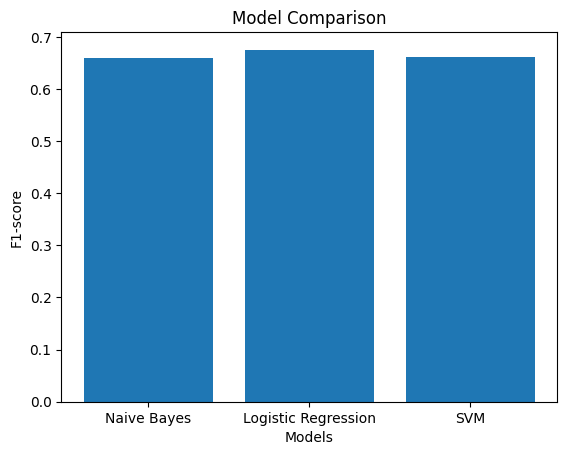

In [ ]:
import matplotlib.pyplot as plt

models = ['Naive Bayes', 'Logistic Regression', 'SVM']
scores = f1_scores.values()

plt.figure()
plt.bar(models, scores)

plt.xlabel("Models")
plt.ylabel("F1-score")
plt.title("Model Comparison")

plt.show()

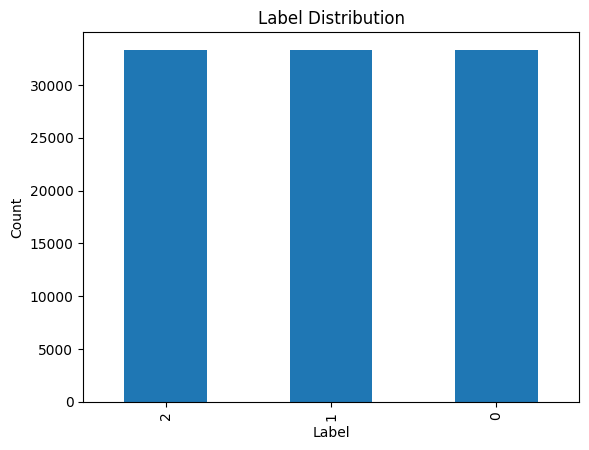

In [36]:
df['label'].value_counts().plot(kind='bar')

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

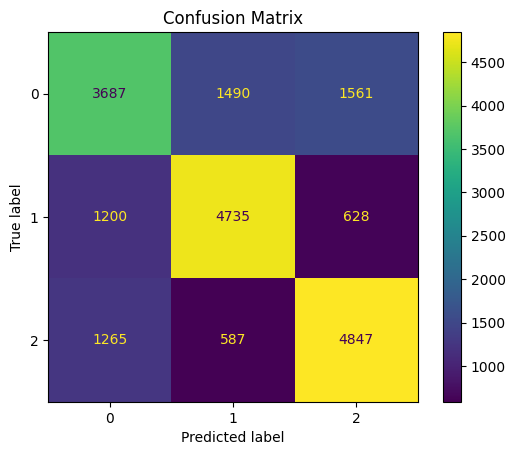

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

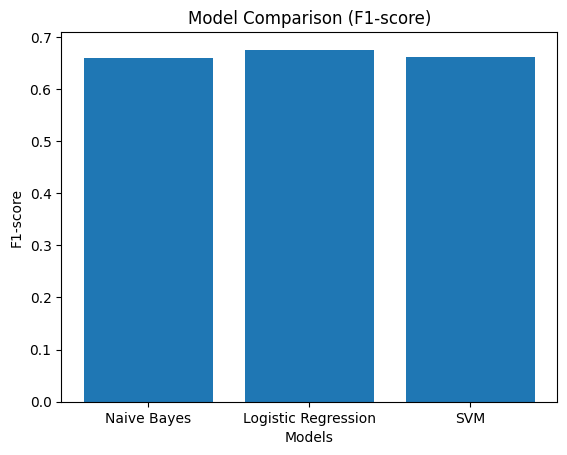

In [37]:
import matplotlib.pyplot as plt

models_names = list(f1_scores.keys())
scores = list(f1_scores.values())

plt.bar(models_names, scores)

plt.title("Model Comparison (F1-score)")
plt.xlabel("Models")
plt.ylabel("F1-score")

plt.show()

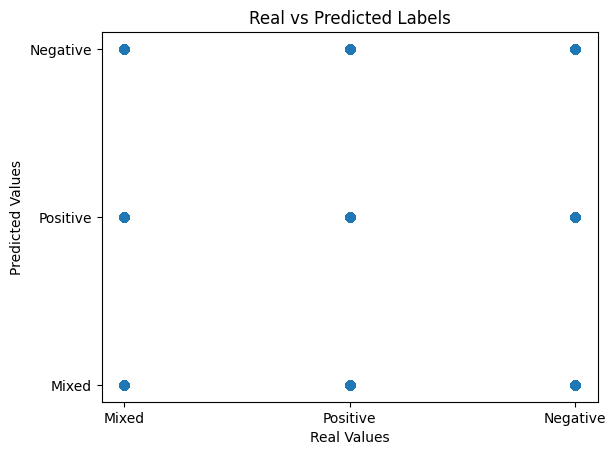

In [38]:
import matplotlib.pyplot as plt

y_pred = best_model.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Real Values")
plt.ylabel("Predicted Values")
plt.title("Real vs Predicted Labels")

plt.show()